# Introdução ao Scikit-Learn e avaliação do modelo

objetivos do aprendizado:

- Explicar a variável de resposta
- Descrever as implicações de dados desbalanceados na classificação binária
- Dividir os dados em conjuntos de treinamento e teste
- Descrever o ajuste do modelo no scikit-learn 
- Derivar varias métricas para a classificação binária
- Criar uma curva ROC e uma curva precision-recall

In [3]:
from sklearn.linear_model import LogisticRegression
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl 
mpl.rcParams['figure.dpi'] = 400

df = pd.read_csv('Data/Chapter_1_cleaned_data.csv')
df['default payment next month'].mean()

np.float64(0.2217971797179718)

In [4]:
df.groupby('default payment next month')['ID'].count()

default payment next month
0    20750
1     5914
Name: ID, dtype: int64

In [5]:
# selecionar o modelo e instancia-lo a partir da classe fornecida pelo scikit-learn
my_new_lr = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100,
                           n_jobs=None, penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
                           verbose=0, warm_start=False)
my_new_lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [6]:
my_new_lr.C = 0.1
my_new_lr.solver = 'liblinear'
my_new_lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [7]:
#tomando emprestadas do dataset as 10 primeiras amostras de uma unica característica
X = df['EDUCATION'][0:10].values.reshape(-1, 1)
X

array([[2],
       [2],
       [2],
       [2],
       [2],
       [1],
       [1],
       [2],
       [3],
       [3]])

In [8]:
y = df['default payment next month'][0:10].values
y

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [9]:
my_new_lr.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [10]:
#já conseguimos utyilizar o modelo treinado para fazer previsões, iremos prever as 10 proximas linhas da característica EDUCATION
new_X = df['EDUCATION'][10:20].values.reshape(-1, 1)
new_X

array([[3],
       [1],
       [2],
       [2],
       [1],
       [3],
       [1],
       [1],
       [1],
       [3]])

In [11]:
# as previsões são feitas utilizando o método predict, iremos prever o y agora
my_new_lr.predict(new_X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [12]:
#rotulos reais correspondentes
df['default payment next month'][10:20].values

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0])

Gerando dados sintéticos

In [13]:
#Gerando dados aleatórios
np.random.seed(seed=1)
X = np.random.uniform(low=0.0, high=10.0, size=(1000,))
X[0:10]

array([4.17022005e+00, 7.20324493e+00, 1.14374817e-03, 3.02332573e+00,
       1.46755891e+00, 9.23385948e-01, 1.86260211e+00, 3.45560727e+00,
       3.96767474e+00, 5.38816734e+00])

Dados para uma regressão linear simples

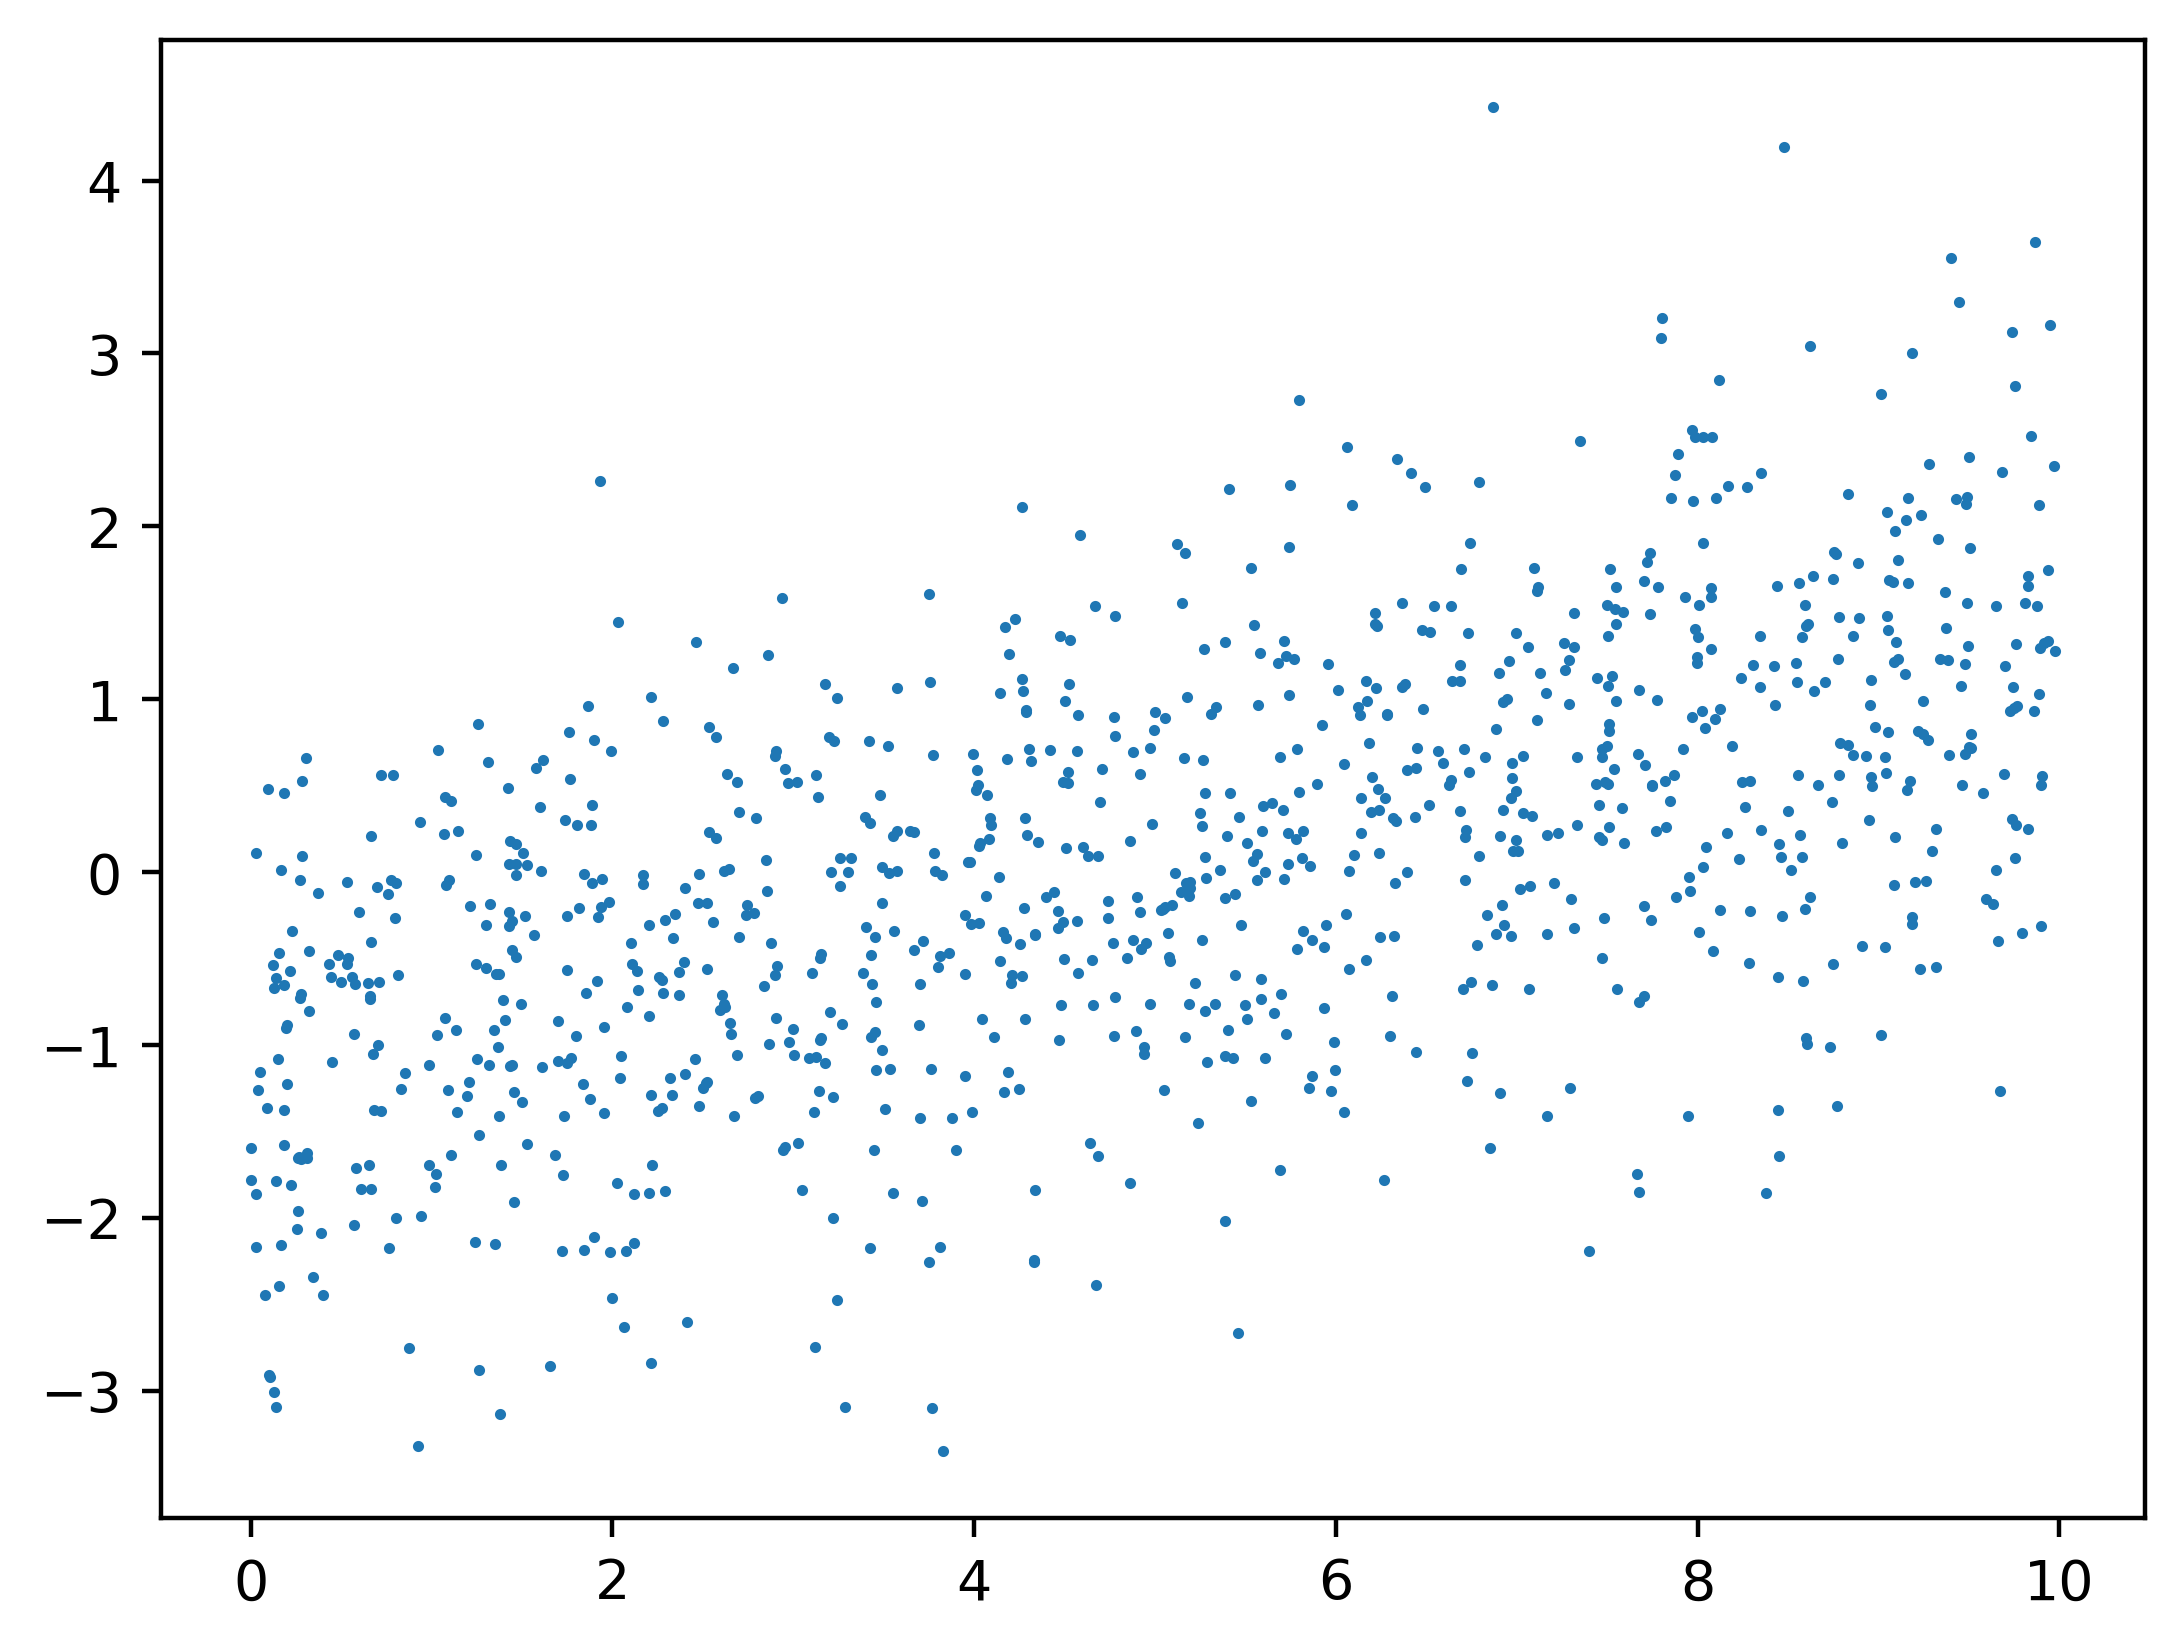

In [14]:
#1. definir o seed aleatorio
np.random.seed(seed=1)

#2. declarar variaveis para a inclinacao e a interceptacao de nossos dados lineares
slope = 0.25
intercept = -1.25

#3.criar a variavel de resposta usando a equacao familiar de uma linha, com o acrescimo de um ruido gaussiano
y = slope * X + np.random.normal(loc=0.0, scale=1.0, size=(1000,)) + intercept

#4. plotar os dados
mpl.rcParams['figure.dpi'] = 400
plt.scatter(X, y, s=1)

Regressao linear com o scikit-learn

In [15]:
#1. importar a classe LinearRegression do modulo linear_model do scikit-learn
from sklearn.linear_model import LinearRegression
#2. instanciar a classe LinearRegression
lin_reg = LinearRegression()
lin_reg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
#1. ajustar o modelo usando nossos dados sinteticos, lembrando de redimensionar o array de características. Para que as amostras fiquem ao longo
#da primeira dimensão
lin_reg.fit(X.reshape(-1, 1), y)
#2. examinar lin_reg.intercept_ e lin_reg.coef_ que contem, respectivamente, a interceptação e o coeficiente (inclinação) da linha ajustada
print(lin_reg.intercept_)
print(lin_reg.coef_)

-1.1612566002825888
[0.24002588]


In [17]:
#fazer as previsões
y_pred = lin_reg.predict(X.reshape(-1, 1))
y_pred[0:10]

array([-0.16029588,  0.56770858, -1.16098207, -0.43558019, -0.80900449,
       -0.93962008, -0.7141839 , -0.33182144, -0.20891199,  0.13204299])

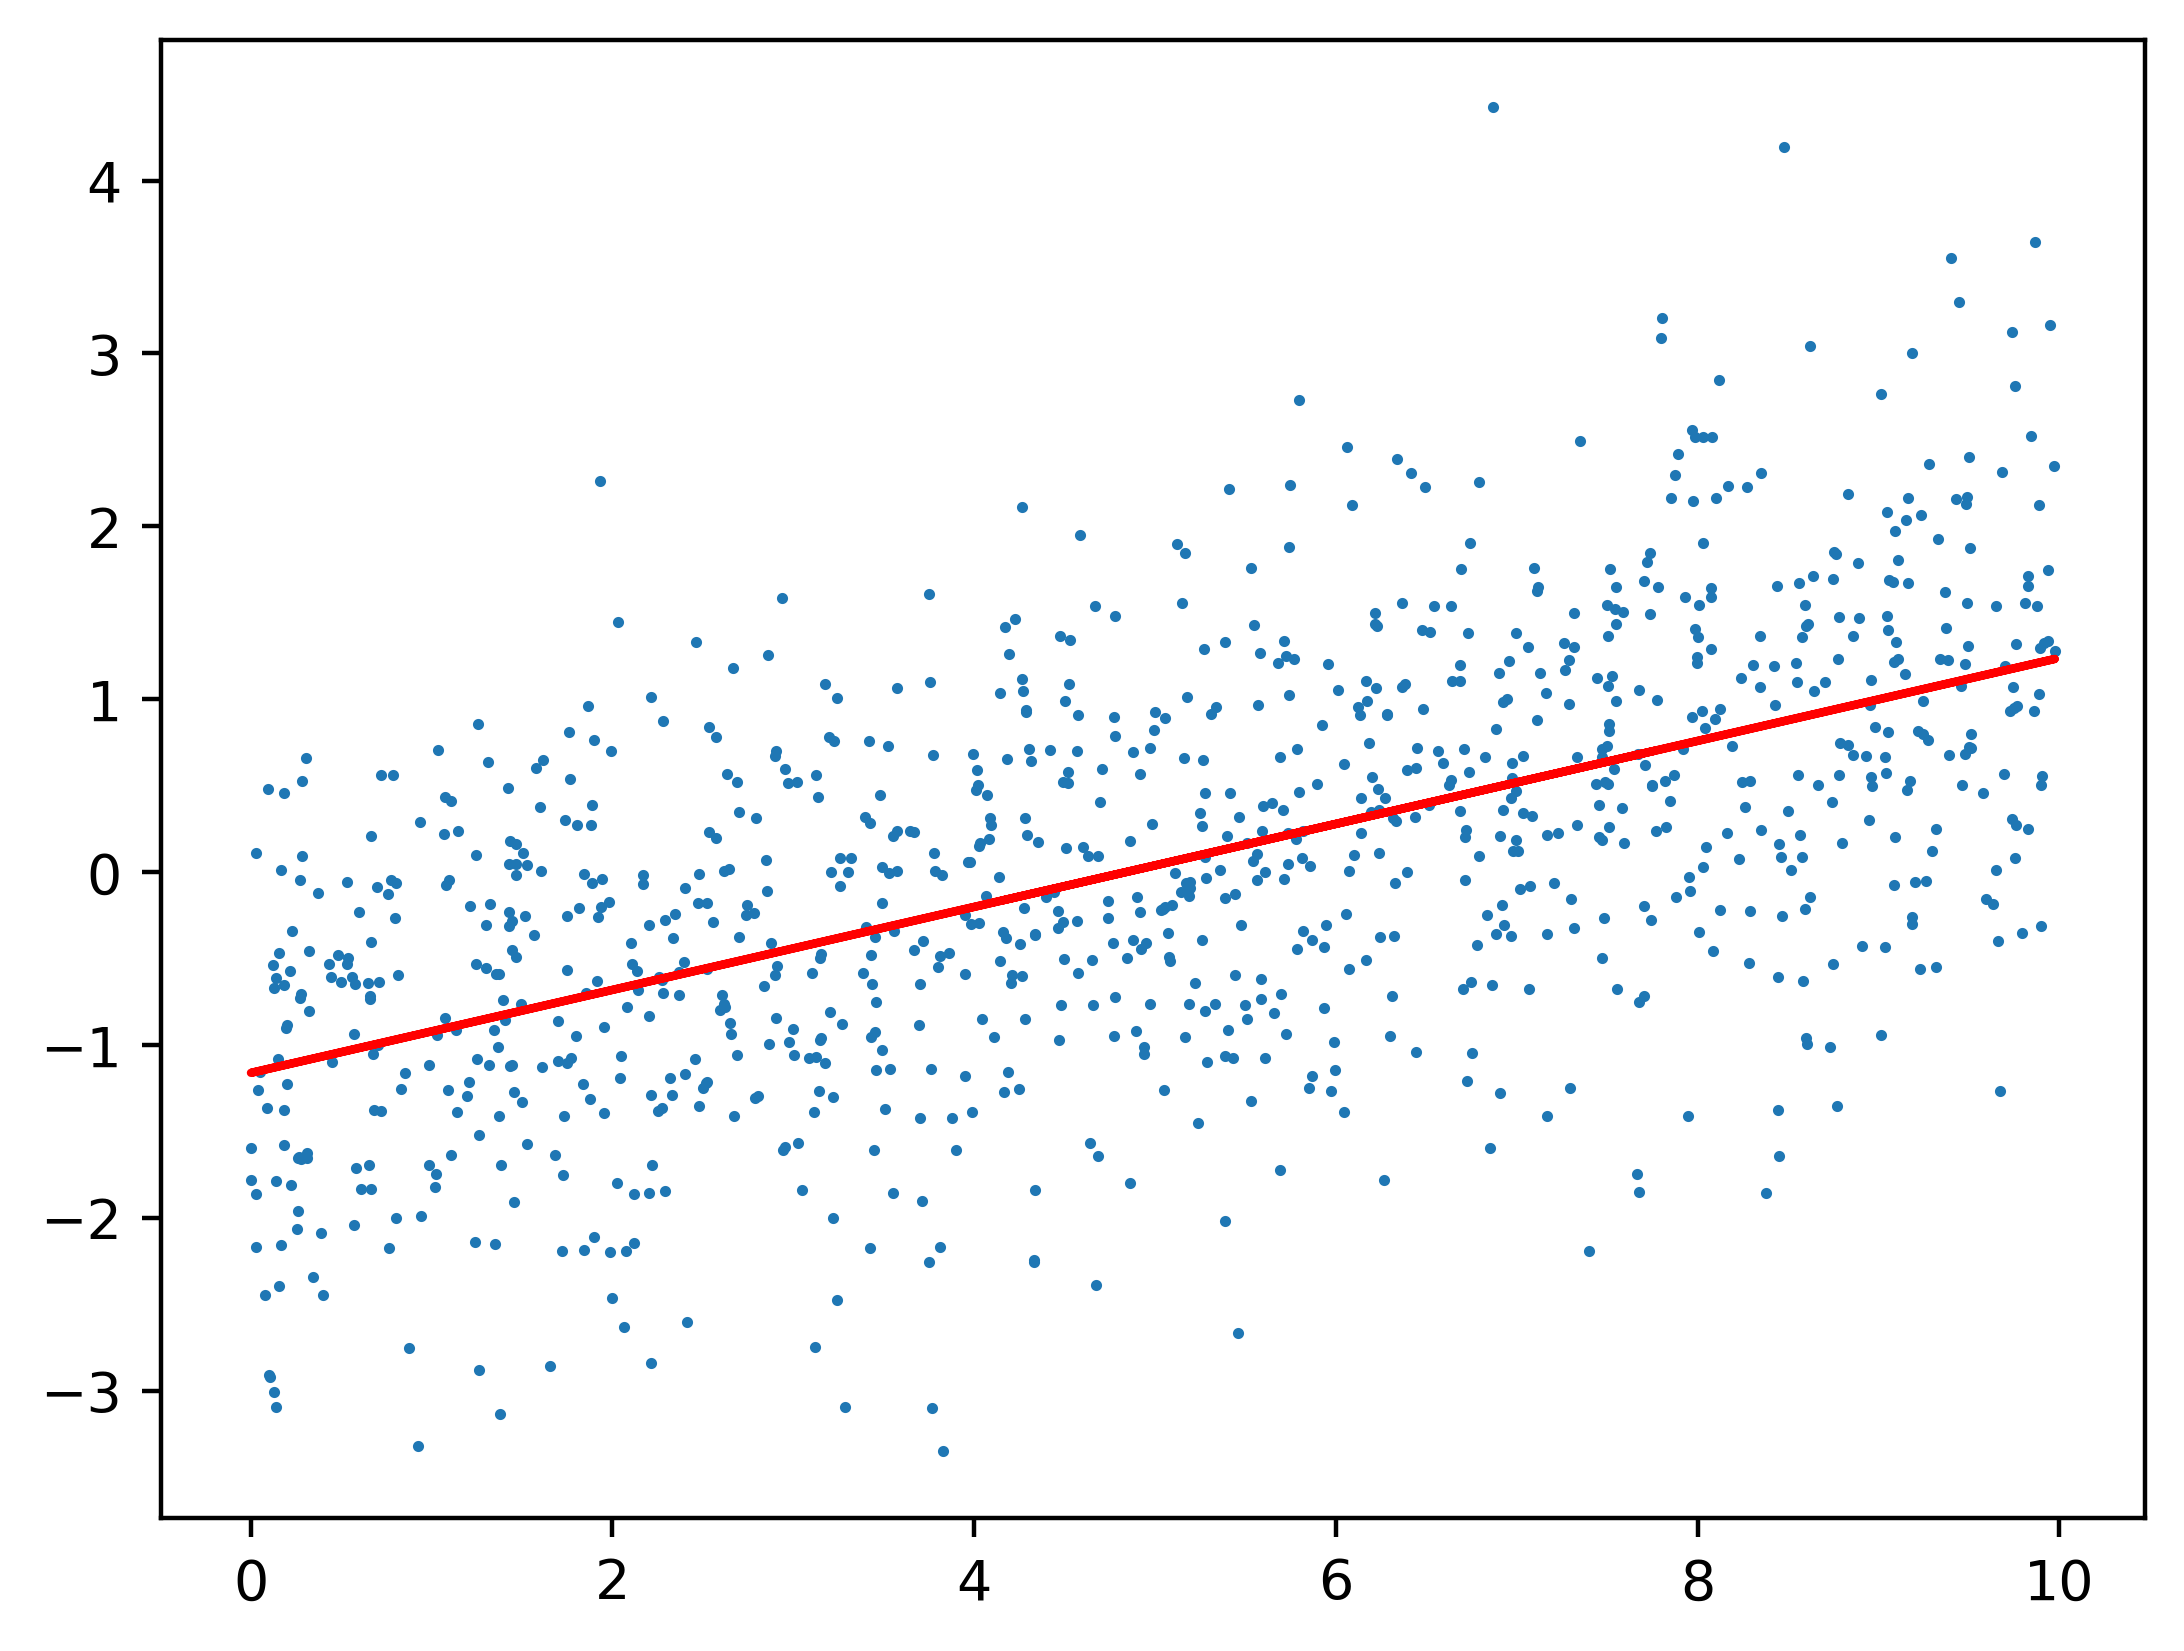

In [18]:
plt.scatter(X, y, s=1)
plt.plot(X, y_pred, 'r')

Enquanto no caso atual estamos vendo como o modelo "ajusta" os mesmos dados com os quais foi treinado, enteriormente examinamos previsoes do modelo para dados novos e desconhecidos, em ML geralmente o que nos interessa sao os recursos preditivos. No entanto, no fim das contas as previsoes tanto dos dados de treinamento usados para ajustar o modelo, quanto dos dados de teste, que nao foram usados no ajuste, sao importantes para entendermos o funcionamento do modelo.

Metricas de desempenho de modelos para a classificacao binaria

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['EDUCATION'].values.reshape(-1, 1), df['default payment next month'].values, test_size=0.2, random_state=24)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((21331, 1), (5333, 1), (21331,), (5333,))

In [20]:
#verificar se a fração de positivos e negativos é aproximadamente a mesma em ambos os conjuntos
np.mean(y_train), np.mean(y_test)

(np.float64(0.223102526838873), np.float64(0.21657603600225014))

acurarica da classificacao

In [21]:
from sklearn.linear_model import LogisticRegression

example_lr = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100,
                           n_jobs=None, penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
                           verbose=0, warm_start=False)
example_lr.fit(X_train, y_train)
y_pred = example_lr.predict(X_test)
y_pred[0:10]   

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
#Acurarica da classificacao
is_correct = y_pred == y_test
np.mean(is_correct)

np.float64(0.7834239639977498)

In [23]:
#outras formas de calcular a acuracia
example_lr.score(X_test, y_test)

0.7834239639977498

In [24]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7834239639977498

In [25]:
P = sum(y_test)
P

np.int64(1155)

In [26]:
TP = sum((y_test == 1) & (y_pred == 1))
TP

np.int64(0)

In [27]:
TPR = TP / P
TPR

np.float64(0.0)

In [28]:
FN = sum((y_test == 1) & (y_pred == 0))
FN

np.int64(1155)

In [29]:
FNR = FN / P
FNR

np.float64(1.0)

In [30]:
N = sum(y_test == 0)
N

np.int64(4178)

In [31]:
TN = sum((y_test == 0) & (y_pred == 0))
TN

np.int64(4178)

In [32]:
FP = sum((y_test == 0) & (y_pred == 1))
FP

np.int64(0)

In [33]:
TNR = TN / N
FPR = FP / N
print('the true negative rate is {} and the false positive rate is {}'.format(TNR, FPR))

the true negative rate is 1.0 and the false positive rate is 0.0


In [34]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[4178,    0],
       [1155,    0]])

In [35]:
#Obtendo probabilidade previstas a partir de um modelo de regressao logistica
y_pred_proba = example_lr.predict_proba(X_test)
y_pred_proba

array([[0.77456295, 0.22543705],
       [0.77456295, 0.22543705],
       [0.79016179, 0.20983821],
       ...,
       [0.79016179, 0.20983821],
       [0.79016179, 0.20983821],
       [0.79016179, 0.20983821]], shape=(5333, 2))

In [36]:
prob_sum = np.sum(y_pred_proba, axis=1)
prob_sum

array([1., 1., 1., ..., 1., 1., 1.], shape=(5333,))

In [37]:
np.unique(prob_sum)

array([1.])

In [38]:
pos_proba = y_pred_proba[:, 1]
pos_proba

array([0.22543705, 0.22543705, 0.20983821, ..., 0.20983821, 0.20983821,
       0.20983821], shape=(5333,))

(array([1883.,    0.,    0., 2519.,    0.,    0.,  849.,    0.,    0.,
          82.]),
 array([0.20983821, 0.21475824, 0.21967826, 0.22459829, 0.22951831,
        0.23443834, 0.23935837, 0.24427839, 0.24919842, 0.25411844,
        0.25903847]),
 <BarContainer object of 10 artists>)

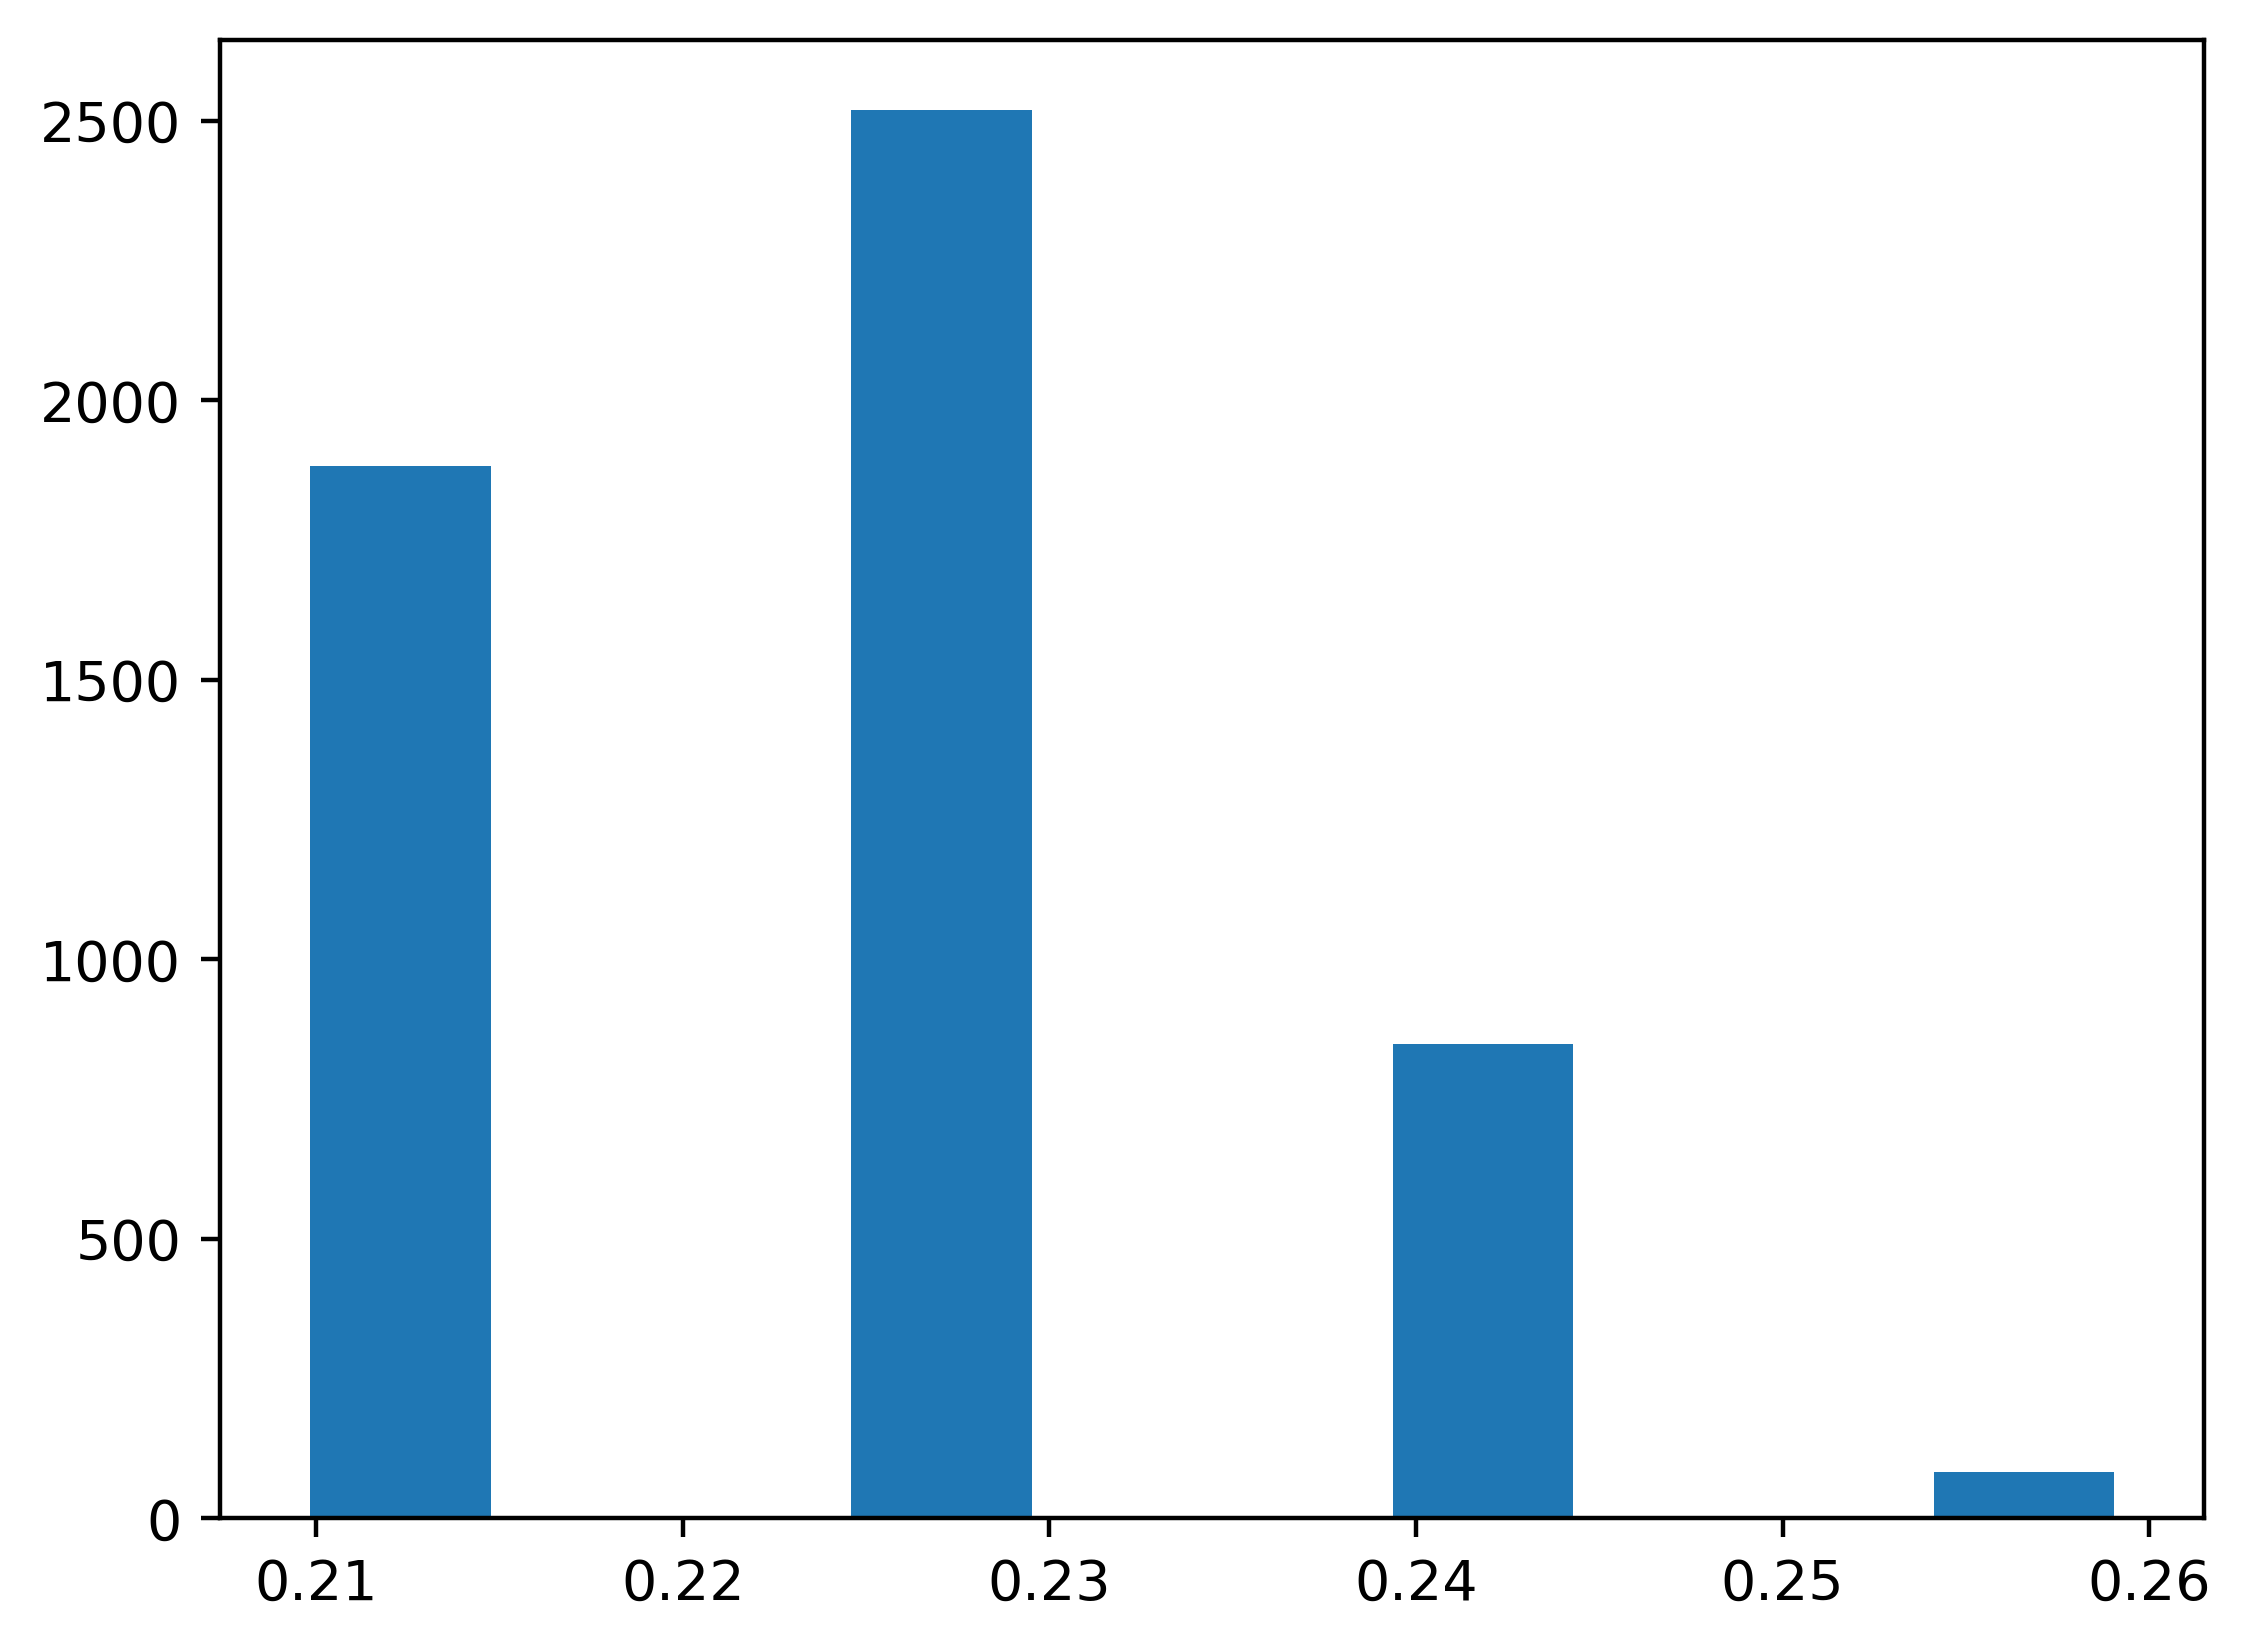

In [39]:
plt.hist(pos_proba)

Text(0, 0.5, 'Number of clients')

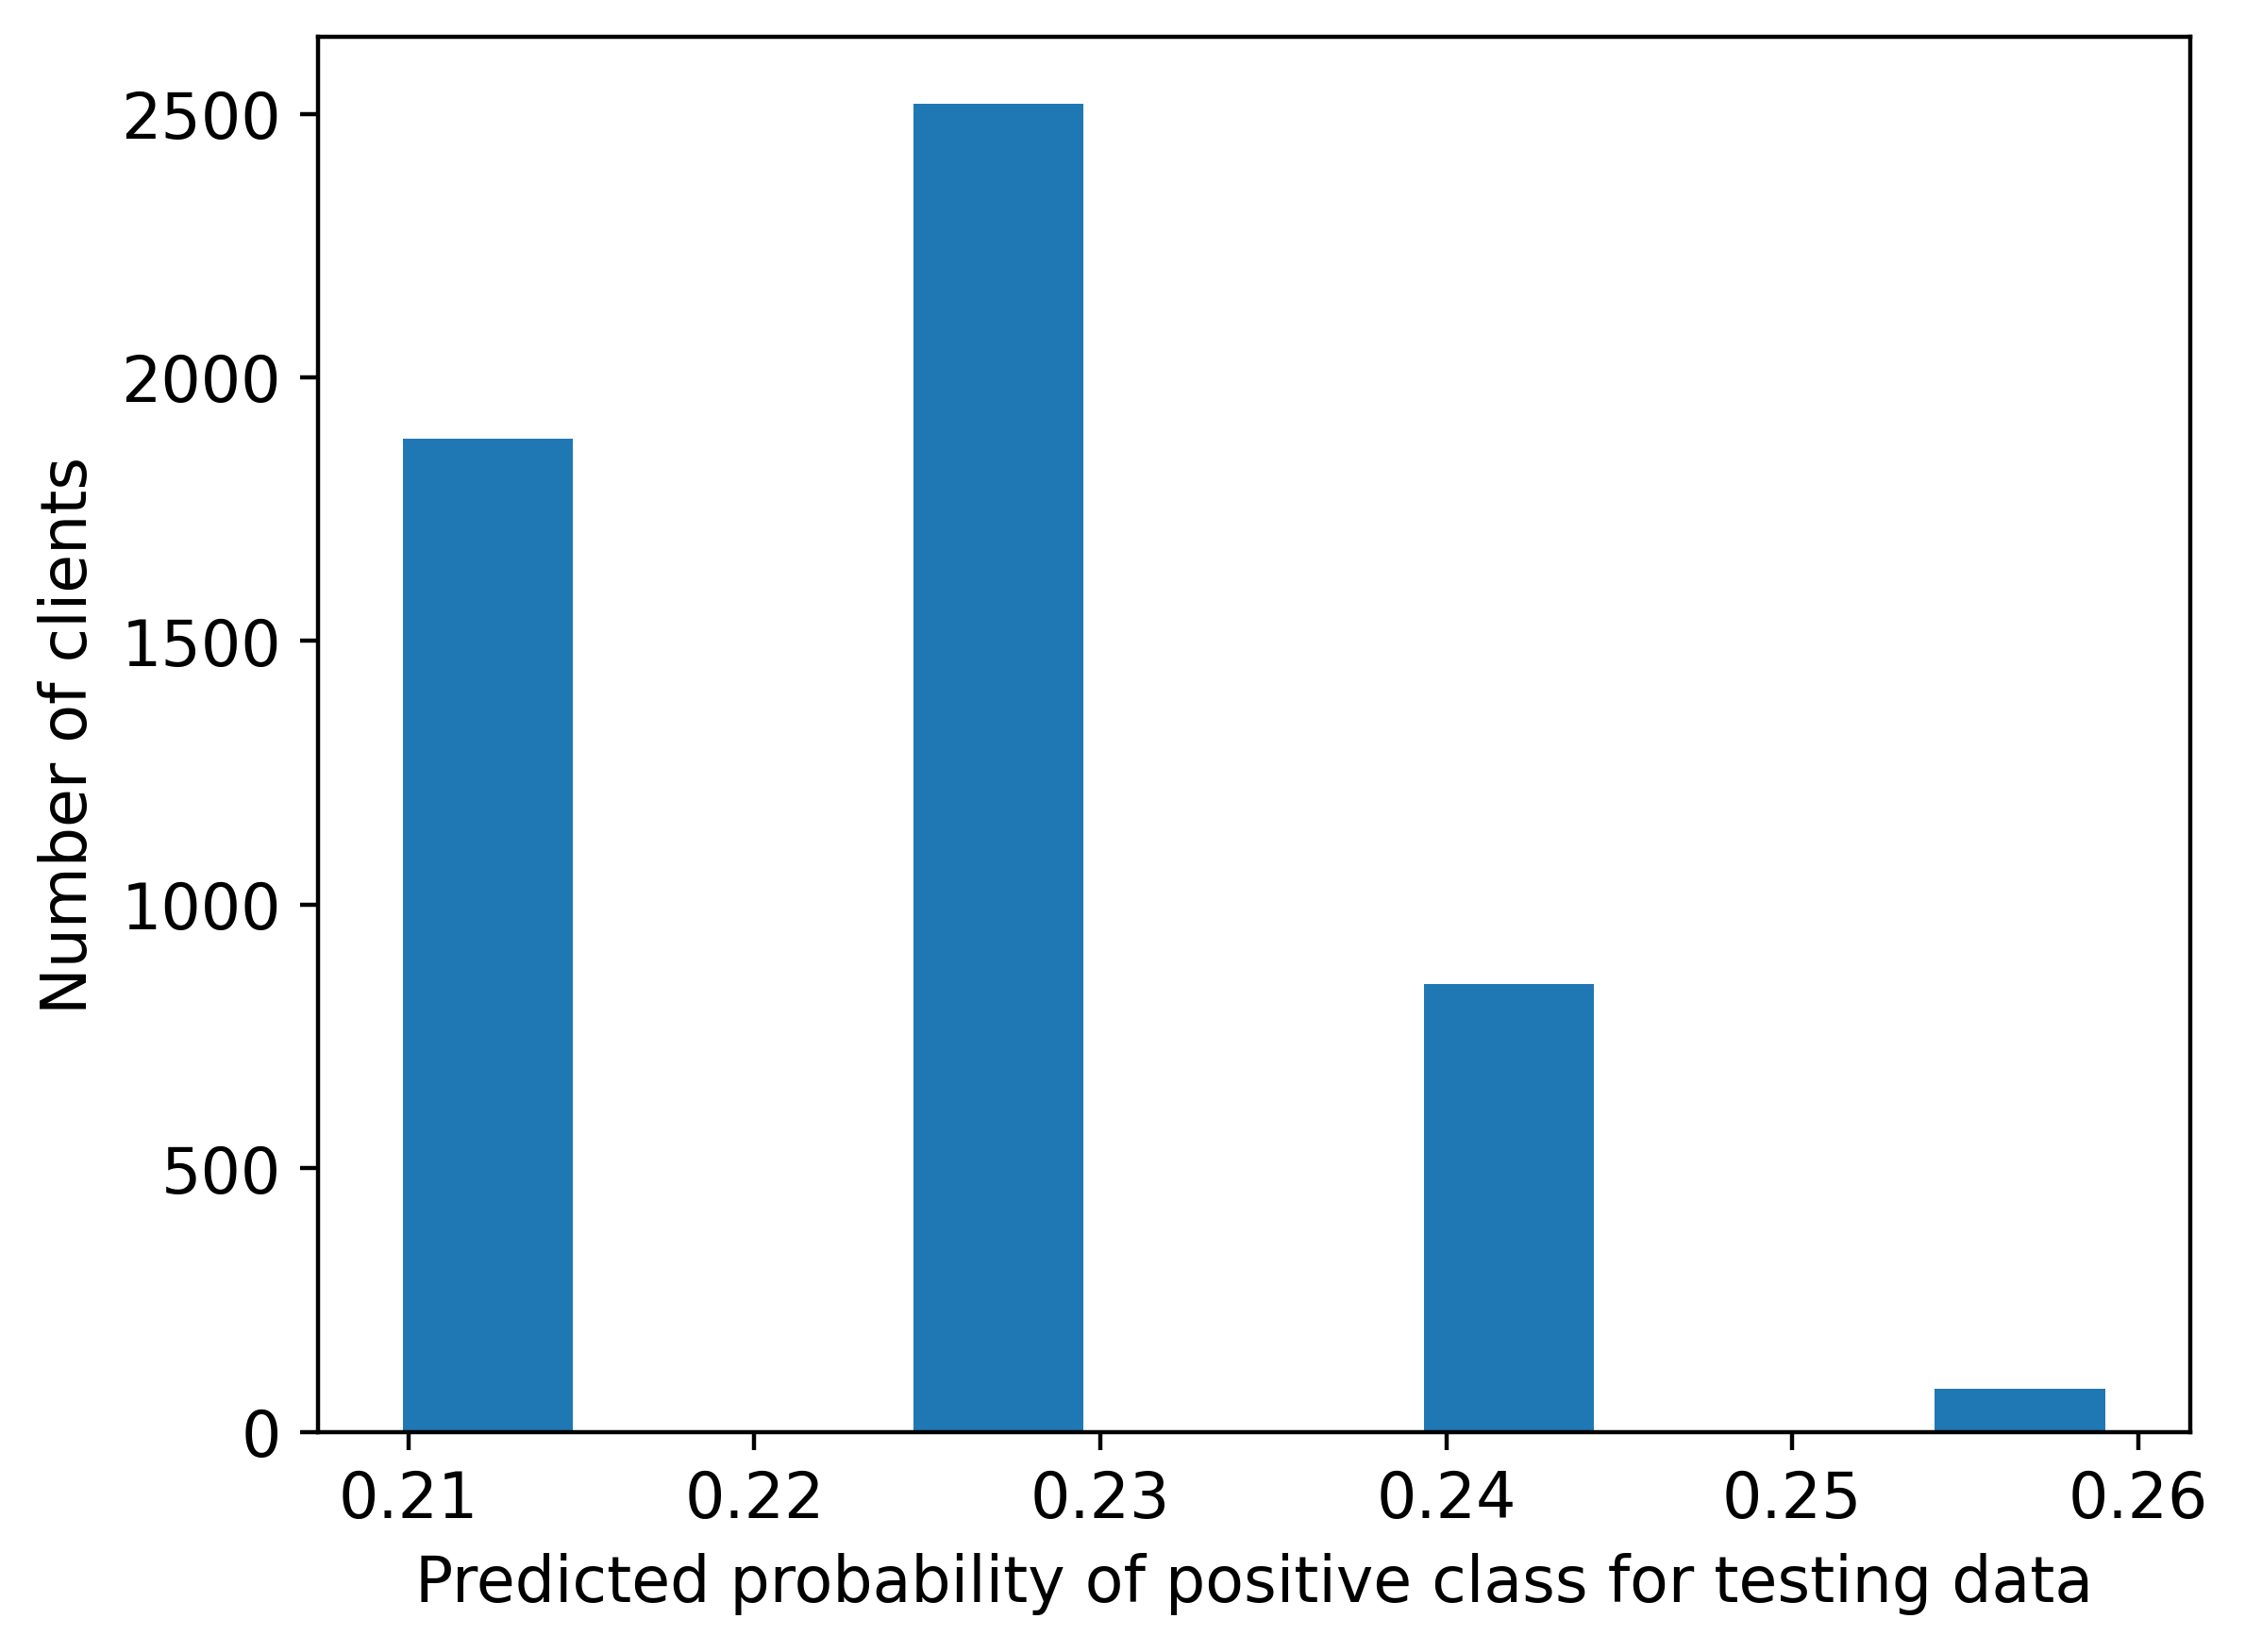

In [40]:
mpl.rcParams['font.size'] = 12
plt.hist(pos_proba)
plt.xlabel('Predicted probability of positive class for testing data')
plt.ylabel('Number of clients')

In [41]:
#Dividindo as probabilidades previstas em duas amostras, uma contendo apenas amostras positivas e outra apenas amostras negativas
pos_sample_pos_proba = pos_proba[y_test == 1]
neg_sample_pos_proba = pos_proba[y_test == 0]

Text(0, 0.5, 'Number of clients')

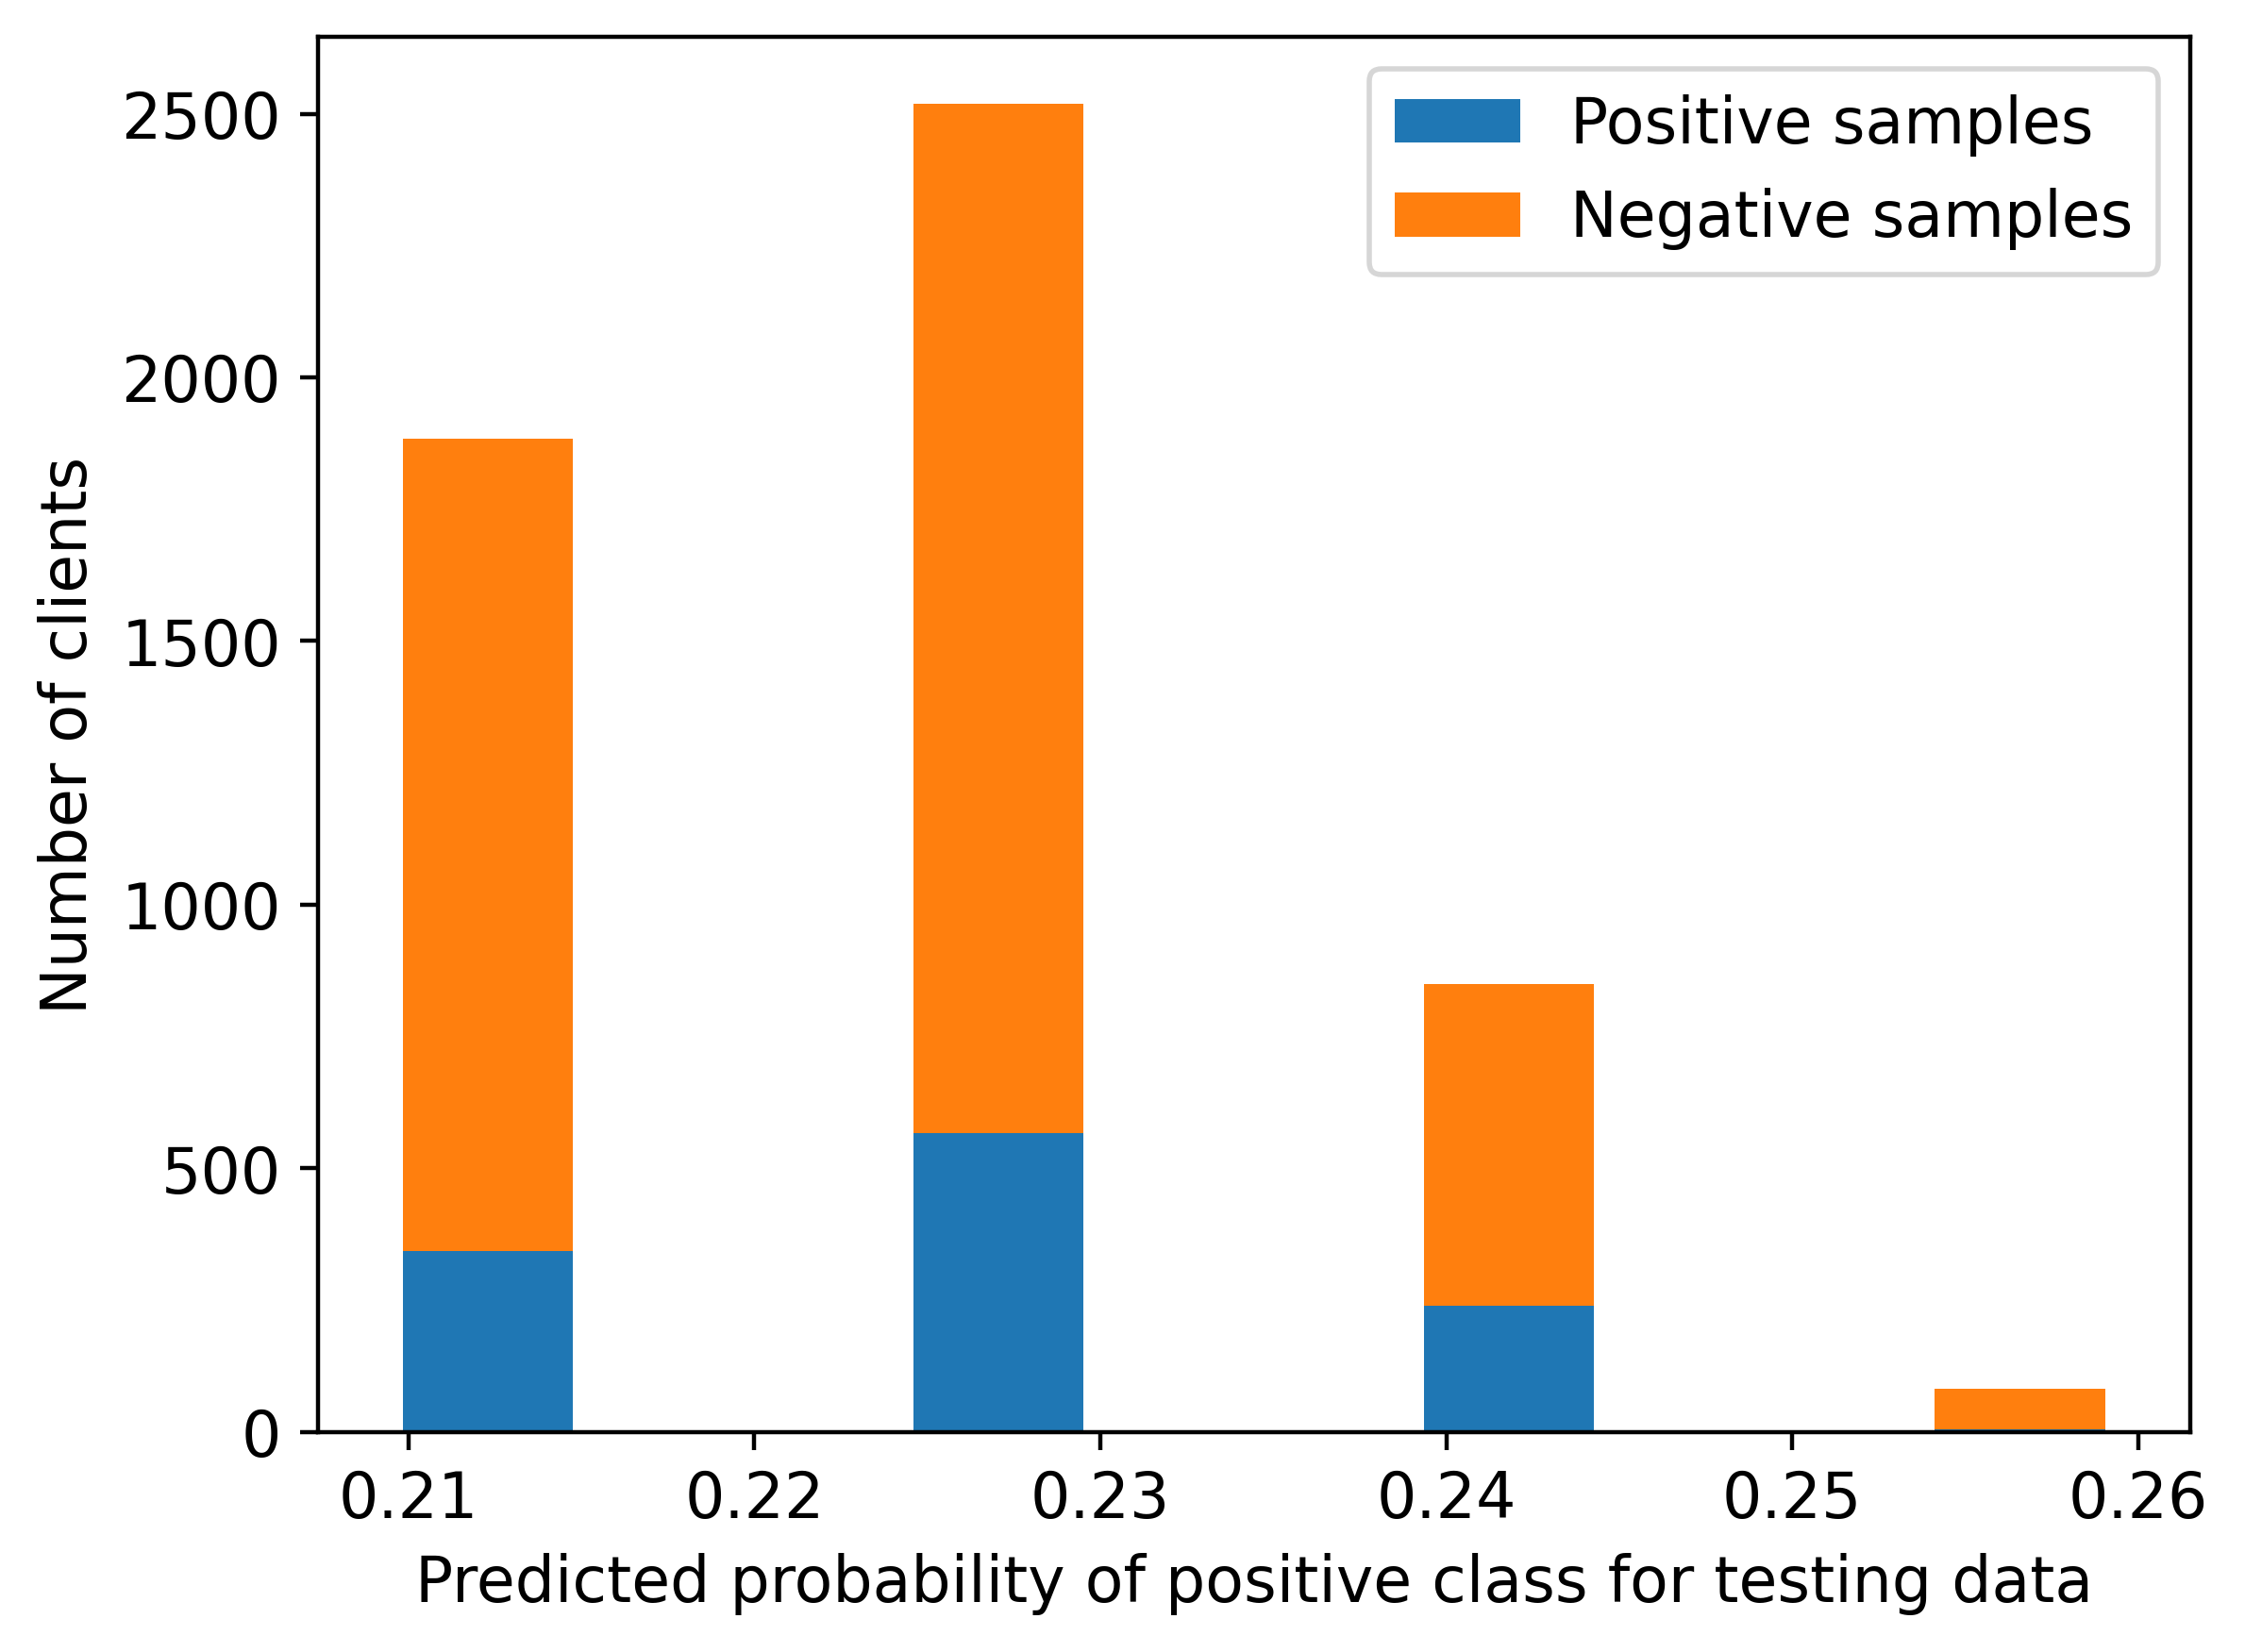

In [42]:
plt.hist([pos_sample_pos_proba, neg_sample_pos_proba], histtype='barstacked')
plt.legend(['Positive samples', 'Negative samples'])
plt.xlabel('Predicted probability of positive class for testing data')
plt.ylabel('Number of clients')

In [43]:
#gerar arrays de TPRs e FPRs da curva de ROC
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, pos_proba)

Text(0.5, 1.0, 'ROC curve for logistic regression model')

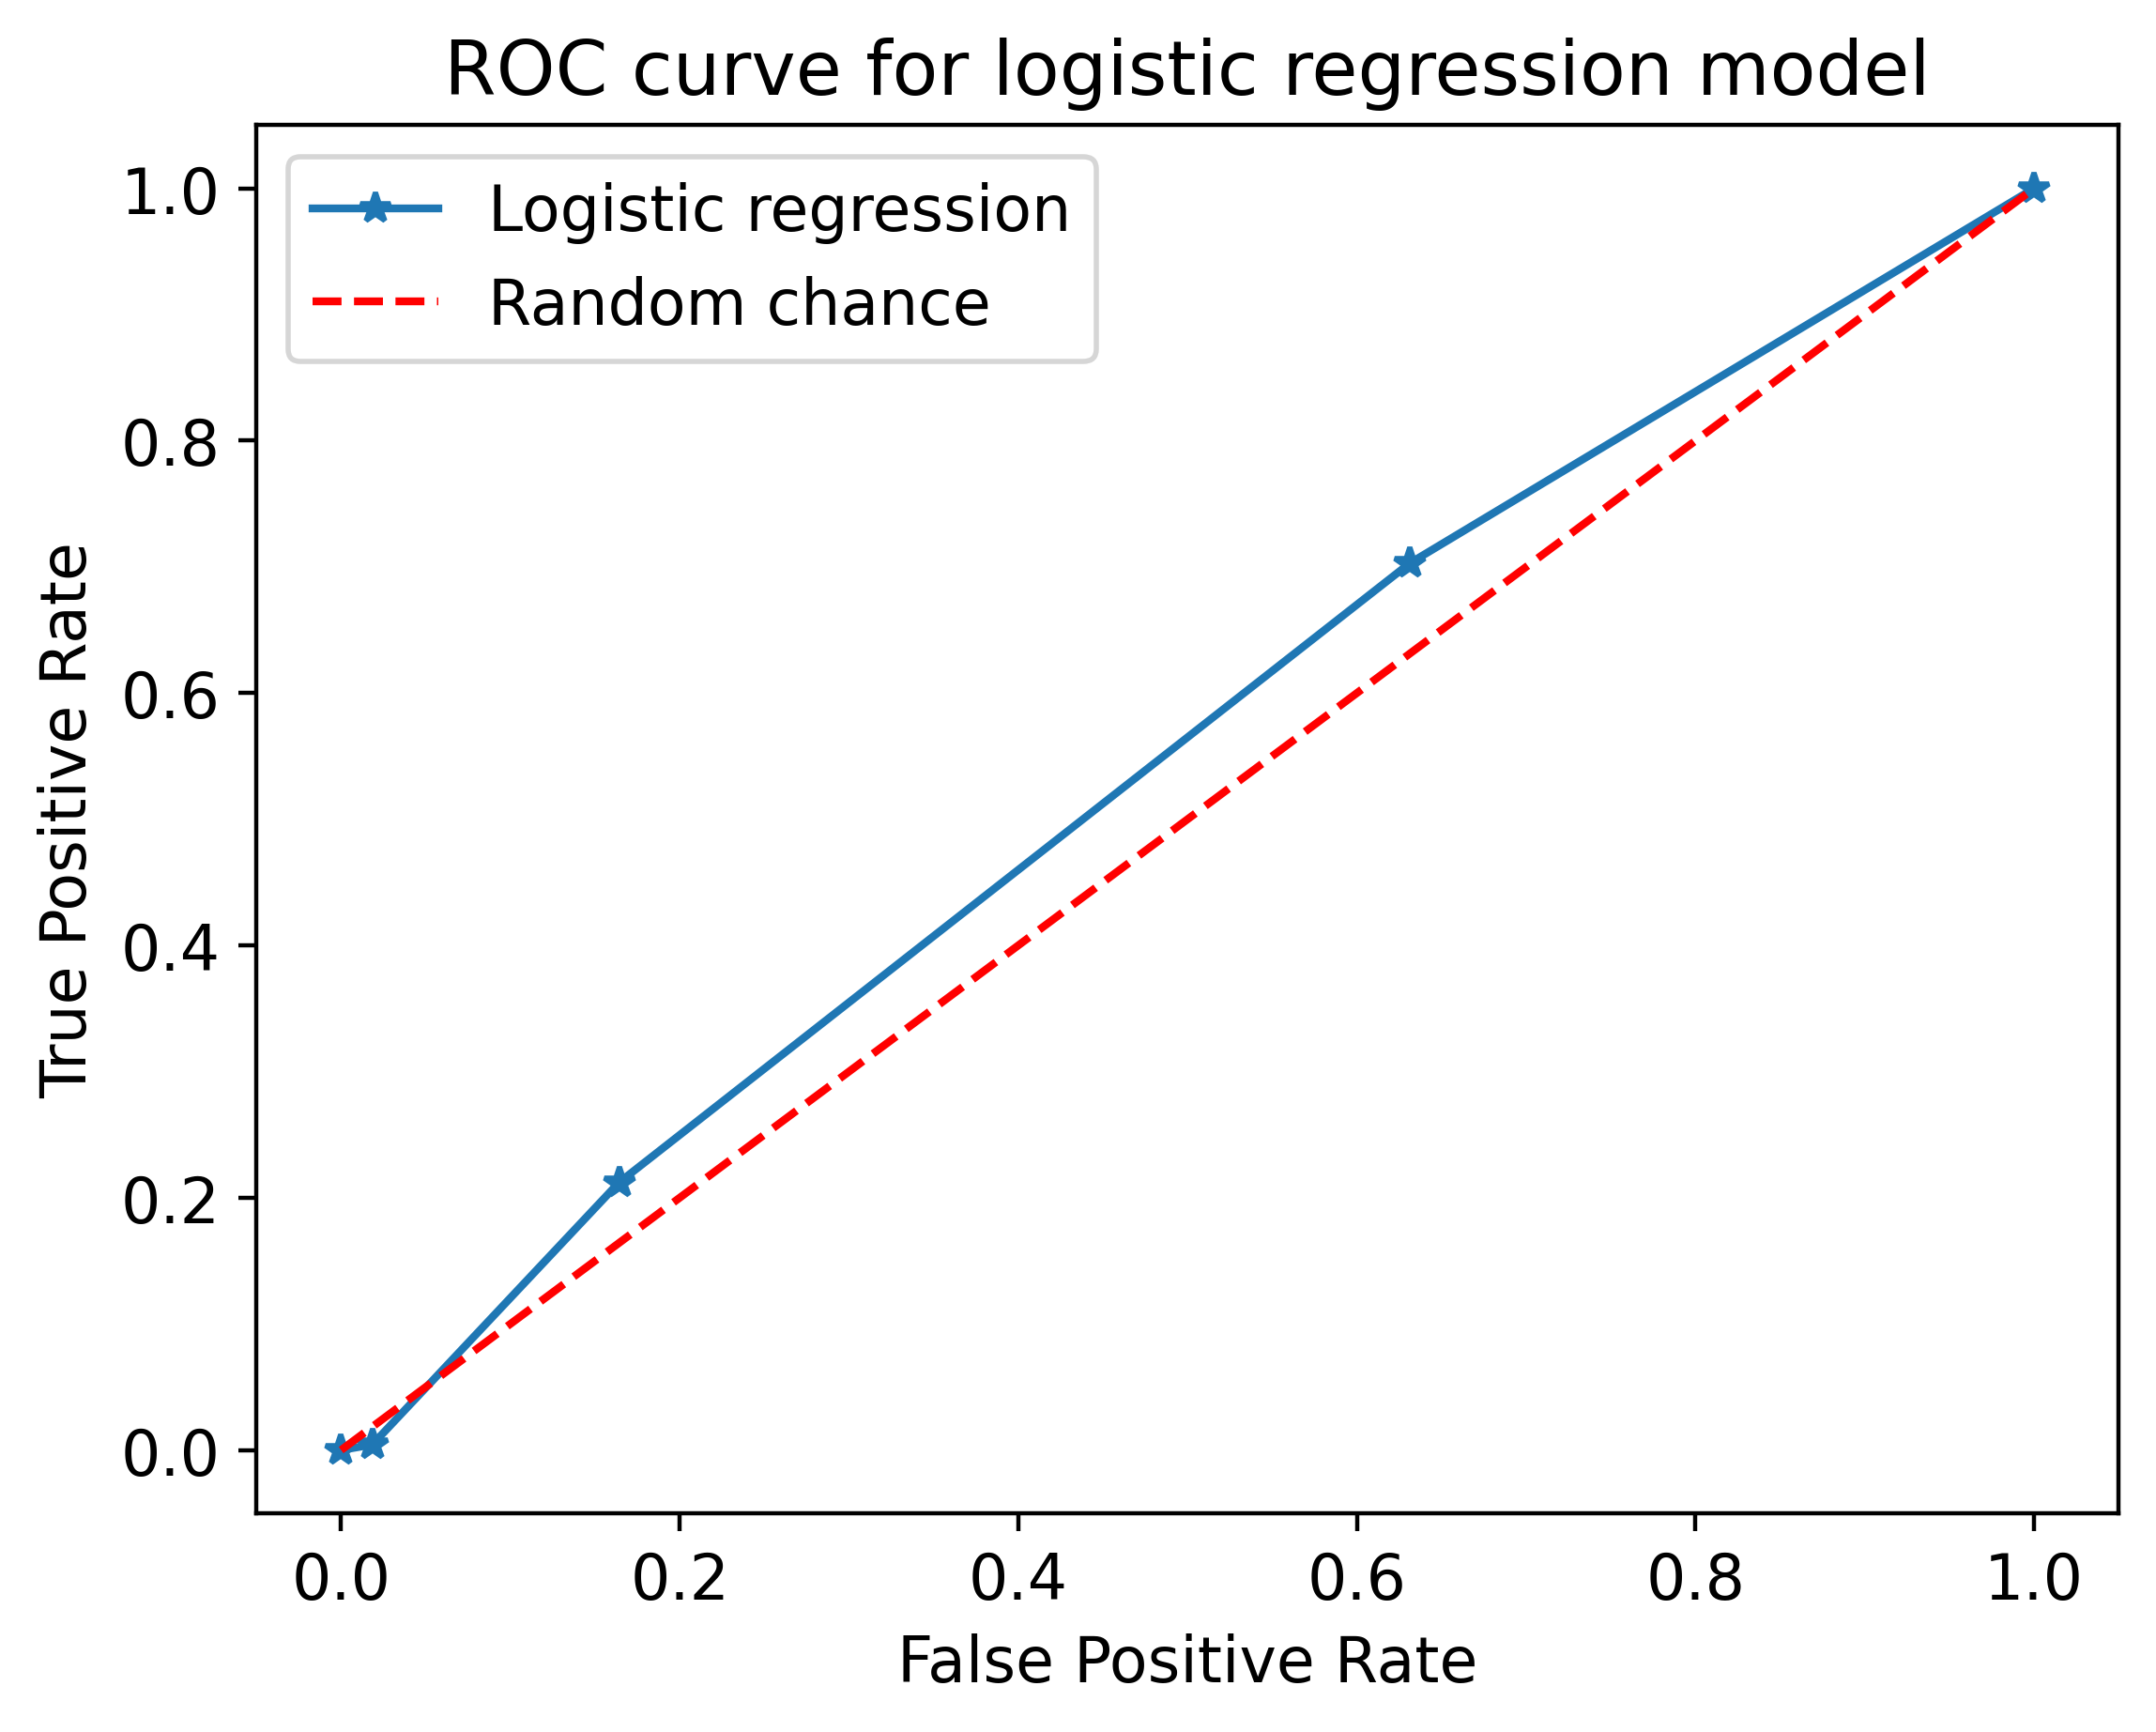

In [44]:
plt.plot(fpr, tpr, '*-')
plt.plot([0, 1], [0, 1], 'r--')
plt.legend(['Logistic regression', 'Random chance'])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for logistic regression model')

In [45]:
thresholds

array([       inf, 0.25903847, 0.24184056, 0.22543705, 0.20983821])

In [46]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, pos_proba)

0.5434650477972642

In [47]:
from sklearn.metrics import precision_recall_curve
precision_recall_curve(y_test, pos_proba)

(array([0.21657604, 0.23536232, 0.26315789, 0.06097561, 1.        ]),
 array([1.        , 0.7030303 , 0.21212121, 0.004329  , 0.        ]),
 array([0.20983821, 0.22543705, 0.24184056, 0.25903847]))